# Fertility Health Dataset

## Fertility Health Analysis & Pregnancy Success Insights

### problem

### Goal

# content

# context

# key features

#### libraries

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv(r"C:\Users\Hp\Downloads\fertility health\Fertility_Health_Dataset_2026.csv")

In [5]:
df.head()

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,NaN,75.7,74.1,13,NaN,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success


In [6]:
df.shape

(800, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Couple_ID                   800 non-null    int64  
 1   Female_Age                  800 non-null    int64  
 2   Male_Age                    800 non-null    int64  
 3   BMI                         800 non-null    float64
 4   Menstrual_Regularity        800 non-null    object 
 5   PCOS                        800 non-null    object 
 6   Stress_Level                800 non-null    object 
 7   Smoking                     800 non-null    object 
 8   Alcohol_Intake              541 non-null    object 
 9   Sperm_Count_Million_per_ml  800 non-null    float64
 10  Motility_%                  800 non-null    float64
 11  Trying_Duration_Months      800 non-null    int64  
 12  Treatment_Type              300 non-null    object 
 13  Pregnancy_Outcome           800 non

# preprocessing

In [8]:
df.isnull().sum()

Couple_ID                       0
Female_Age                      0
Male_Age                        0
BMI                             0
Menstrual_Regularity            0
PCOS                            0
Stress_Level                    0
Smoking                         0
Alcohol_Intake                259
Sperm_Count_Million_per_ml      0
Motility_%                      0
Trying_Duration_Months          0
Treatment_Type                500
Pregnancy_Outcome               0
dtype: int64

In [9]:
df['Alcohol_Intake']=df['Alcohol_Intake'].fillna("unknown")

In [10]:
df.isnull().sum()

Couple_ID                       0
Female_Age                      0
Male_Age                        0
BMI                             0
Menstrual_Regularity            0
PCOS                            0
Stress_Level                    0
Smoking                         0
Alcohol_Intake                  0
Sperm_Count_Million_per_ml      0
Motility_%                      0
Trying_Duration_Months          0
Treatment_Type                500
Pregnancy_Outcome               0
dtype: int64

In [11]:
df.head()

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,unknown,75.7,74.1,13,NaN,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,NaN,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,NaN,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,NaN,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Treatment_Type']=df['Treatment_Type'].fillna("No treatment")

In [14]:
df.head()

,Couple_ID,Female_Age,Male_Age,BMI,Menstrual_Regularity,PCOS,Stress_Level,Smoking,Alcohol_Intake,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Treatment_Type,Pregnancy_Outcome
0,1,26,35,22.6,Regular,No,High,No,unknown,75.7,74.1,13,No treatment,Success
1,2,39,30,28.0,Regular,No,High,Yes,Moderate,25.2,27.4,35,No treatment,Failure
2,3,34,35,24.1,Regular,Yes,Low,No,High,64.0,74.5,13,No treatment,Success
3,4,30,22,19.6,Regular,No,High,No,High,87.3,31.9,31,No treatment,Success
4,5,27,40,33.6,Irregular,No,Low,No,High,116.9,51.3,21,Medication,Success


In [15]:
df.isnull().sum()

Couple_ID                     0
Female_Age                    0
Male_Age                      0
BMI                           0
Menstrual_Regularity          0
PCOS                          0
Stress_Level                  0
Smoking                       0
Alcohol_Intake                0
Sperm_Count_Million_per_ml    0
Motility_%                    0
Trying_Duration_Months        0
Treatment_Type                0
Pregnancy_Outcome             0
dtype: int64

# eda

In [27]:
df.columns

Index(['Female_Age', 'Male_Age', 'BMI', 'Menstrual_Regularity', 'PCOS',
       'Stress_Level', 'Smoking', 'Alcohol_Intake',
       'Sperm_Count_Million_per_ml', 'Motility_%', 'Trying_Duration_Months',
       'Treatment_Type', 'Pregnancy_Outcome'],
      dtype='object')

## Separating Categorical and Numerical columns

In [28]:
cat_col=df.dtypes[df.dtypes=="object"].index #separating num and cat
num_col=df.dtypes[df.dtypes!="object"].index

In [29]:
cat_col

Index(['Menstrual_Regularity', 'PCOS', 'Stress_Level', 'Smoking',
       'Alcohol_Intake', 'Treatment_Type', 'Pregnancy_Outcome'],
      dtype='object')

#### Menstrual_Regularity

In [30]:
df['Menstrual_Regularity'].unique()

array(['Regular', 'Irregular'], dtype=object)

In [31]:
df['Menstrual_Regularity'].value_counts()

Menstrual_Regularity
Regular      559
Irregular    241
Name: count, dtype: int64

In [32]:
df['Menstrual_Regularity'].value_counts(normalize=True)*100

Menstrual_Regularity
Regular      69.875
Irregular    30.125
Name: proportion, dtype: float64

###### Majority (70%) have regular cycles,(30%) irregular → significant subgroup affecting fertility Menstrual_Regularity is a strong candidate feature.Likely correlated with:PCOS,Pregnancy outcome (lower success for irregular)

#### PCOS

In [33]:
df['PCOS'].unique()

array(['No', 'Yes'], dtype=object)

In [34]:
df['PCOS'].value_counts()

PCOS
No     643
Yes    157
Name: count, dtype: int64

In [35]:
df['PCOS'].value_counts(normalize=True)*100

PCOS
No     80.375
Yes    19.625
Name: proportion, dtype: float64

#### Stress_Level

In [36]:
df['Stress_Level'].unique()

array(['High', 'Low', 'Medium'], dtype=object)

In [37]:
df['Stress_Level'].value_counts()

Stress_Level
High      286
Medium    261
Low       253
Name: count, dtype: int64

In [38]:
df['Stress_Level'].value_counts(normalize=True)*100

Stress_Level
High      35.750
Medium    32.625
Low       31.625
Name: proportion, dtype: float64

### Smoking

In [39]:
df['Smoking'].unique()

array(['No', 'Yes'], dtype=object)

In [40]:
df['Smoking'].value_counts()

Smoking
No     540
Yes    260
Name: count, dtype: int64

In [41]:
df['Smoking'].value_counts(normalize=True)*100

Smoking
No     67.5
Yes    32.5
Name: proportion, dtype: float64

### Alcohol_Intake

In [42]:
df['Alcohol_Intake'].unique()

array(['unknown', 'Moderate', 'High'], dtype=object)

In [43]:
df['Alcohol_Intake'].value_counts()

Alcohol_Intake
Moderate    297
unknown     259
High        244
Name: count, dtype: int64

In [44]:
df['Alcohol_Intake'].value_counts(normalize=True)*100

Alcohol_Intake
Moderate    37.125
unknown     32.375
High        30.500
Name: proportion, dtype: float64

### Treatment_Type

In [45]:
df['Treatment_Type'].unique()

array(['No treatment', 'Medication', 'IVF'], dtype=object)

In [46]:
df['Treatment_Type'].value_counts()

Treatment_Type
No treatment    500
Medication      196
IVF             104
Name: count, dtype: int64

In [47]:
df['Treatment_Type'].value_counts(normalize=True)*100

Treatment_Type
No treatment    62.5
Medication      24.5
IVF             13.0
Name: proportion, dtype: float64

### Pregnancy_Outcome

In [48]:
df['Pregnancy_Outcome'].unique()

array(['Success', 'Failure'], dtype=object)

In [49]:
df['Pregnancy_Outcome'].value_counts()

Pregnancy_Outcome
Success    582
Failure    218
Name: count, dtype: int64

In [50]:
df['Pregnancy_Outcome'].value_counts(normalize=True)*100

Pregnancy_Outcome
Success    72.75
Failure    27.25
Name: proportion, dtype: float64

### num_col

In [ ]:
df = df.drop(columns=['Couple_ID'])

In [51]:
df['Female_Age'].mean()

np.float64(31.9075)

In [52]:
df['BMI'].mean()

np.float64(26.647)

In [53]:
df['Male_Age'].mean()

np.float64(35.255)

In [54]:
df['Sperm_Count_Million_per_ml'].mean()

np.float64(61.071999999999996)

In [55]:
df['Motility_%'].mean()

np.float64(54.955)

In [56]:
df['Trying_Duration_Months'].mean()

np.float64(18.30875)

In [57]:
df[num_col].mean()

Female_Age                    31.90750
Male_Age                      35.25500
BMI                           26.64700
Sperm_Count_Million_per_ml    61.07200
Motility_%                    54.95500
Trying_Duration_Months        18.30875
dtype: float64

In [58]:
df[num_col].std()

Female_Age                     7.461806
Male_Age                       8.216865
BMI                            4.996724
Sperm_Count_Million_per_ml    34.207898
Motility_%                    19.767997
Trying_Duration_Months         9.958156
dtype: float64

In [59]:
df[num_col].max()

Female_Age                     44.0
Male_Age                       49.0
BMI                            35.0
Sperm_Count_Million_per_ml    119.9
Motility_%                     90.0
Trying_Duration_Months         35.0
dtype: float64

In [60]:
df[num_col].var()

Female_Age                      55.678542
Male_Age                        67.516871
BMI                             24.967250
Sperm_Count_Million_per_ml    1170.180316
Motility_%                     390.773692
Trying_Duration_Months          99.164880
dtype: float64

In [61]:
df[num_col].min()

Female_Age                    20.0
Male_Age                      22.0
BMI                           18.1
Sperm_Count_Million_per_ml     5.1
Motility_%                    20.1
Trying_Duration_Months         1.0
dtype: float64

In [63]:
df[num_col].describe().T

,count,mean,std,min,25%,50%,75%,max
Female_Age,800.0,31.90750,7.461806,20.0,25.000,32.00,39.000,44.0
Male_Age,800.0,35.25500,8.216865,22.0,28.000,35.00,43.000,49.0
BMI,800.0,26.64700,4.996724,18.1,22.100,26.80,31.000,35.0
Sperm_Count_Million_per_ml,800.0,61.07200,34.207898,5.1,30.600,61.05,90.825,119.9
Motility_%,800.0,54.95500,19.767997,20.1,38.275,55.55,71.100,90.0
Trying_Duration_Months,800.0,18.30875,9.958156,1.0,10.000,18.00,27.000,35.0


## bivariate

### cat-cat

In [64]:
cat_col

Index(['Menstrual_Regularity', 'PCOS', 'Stress_Level', 'Smoking',
       'Alcohol_Intake', 'Treatment_Type', 'Pregnancy_Outcome'],
      dtype='object')

In [65]:
pd.crosstab(df['Menstrual_Regularity'], df['Stress_Level'], normalize='index')

Stress_Level,High,Low,Medium
Menstrual_Regularity,,,
Irregular,0.348548,0.311203,0.340249
Regular,0.361360,0.318426,0.320215


In [66]:
pd.crosstab(df['Menstrual_Regularity'], df['Stress_Level'])

Stress_Level,High,Low,Medium
Menstrual_Regularity,,,
Irregular,84,75,82
Regular,202,178,179


In [67]:
pd.crosstab(df['Pregnancy_Outcome'], df['Alcohol_Intake'])

Alcohol_Intake,High,Moderate,unknown
Pregnancy_Outcome,,,
Failure,62,77,79
Success,182,220,180


In [68]:
pd.crosstab(df['Pregnancy_Outcome'], df['Smoking'])

Smoking,No,Yes
Pregnancy_Outcome,,
Failure,137,81
Success,403,179


In [69]:
pd.crosstab(df['Pregnancy_Outcome'], df['Treatment_Type'])

Treatment_Type,IVF,Medication,No treatment
Pregnancy_Outcome,,,
Failure,18,52,148
Success,86,144,352


In [70]:
pd.crosstab(df['Pregnancy_Outcome'], df['PCOS'])

PCOS,No,Yes
Pregnancy_Outcome,,
Failure,160,58
Success,483,99


In [71]:
pd.crosstab(df['Pregnancy_Outcome'], df['Menstrual_Regularity'])

Menstrual_Regularity,Irregular,Regular
Pregnancy_Outcome,,
Failure,61,157
Success,180,402


In [72]:
pd.crosstab(df['Stress_Level'], df['PCOS'])

PCOS,No,Yes
Stress_Level,,
High,240,46
Low,202,51
Medium,201,60


### cat-num

In [73]:
cat_col

Index(['Menstrual_Regularity', 'PCOS', 'Stress_Level', 'Smoking',
       'Alcohol_Intake', 'Treatment_Type', 'Pregnancy_Outcome'],
      dtype='object')

In [74]:
num_col

Index(['Female_Age', 'Male_Age', 'BMI', 'Sperm_Count_Million_per_ml',
       'Motility_%', 'Trying_Duration_Months'],
      dtype='object')

In [75]:
df.groupby('Pregnancy_Outcome')[['Female_Age','Male_Age',
                           'BMI','Motility_%']].mean()

,Female_Age,Male_Age,BMI,Motility_%
Pregnancy_Outcome,,,,
Failure,37.56422,34.752294,27.033945,46.493578
Success,29.78866,35.443299,26.502062,58.124399


In [76]:
df.groupby('Smoking')[['Female_Age','Male_Age',
                           'BMI','Motility_%']].mean()

,Female_Age,Male_Age,BMI,Motility_%
Smoking,,,,
No,32.161111,35.622222,26.615926,55.204074
Yes,31.380769,34.492308,26.711538,54.437692


In [77]:
df.groupby('Stress_Level')[['Female_Age','Male_Age',
                           'BMI','Motility_%']].mean()

,Female_Age,Male_Age,BMI,Motility_%
Stress_Level,,,,
High,32.006993,34.874126,27.312238,56.113636
Low,32.083004,35.399209,26.330040,52.703557
Medium,31.628352,35.532567,26.225287,55.867816


In [78]:
df.groupby('Treatment_Type')[['Female_Age','Male_Age',
                           'BMI','Motility_%']].mean()

,Female_Age,Male_Age,BMI,Motility_%
Treatment_Type,,,,
IVF,31.692308,34.778846,26.696154,55.919231
Medication,32.005102,35.301020,26.694898,55.025000
No treatment,31.914000,35.336000,26.618000,54.727000


In [79]:
df.groupby("Pregnancy_Outcome").agg({"Female_Age": ["min", "max", "mean", "std", "count"]}) 

Female_Age                              
                         min max      mean       std count
Pregnancy_Outcome                                         
Failure                   21  44  37.56422  5.537306   218
Success                   20  44  29.78866  6.972408   582

In [80]:
df.groupby("Pregnancy_Outcome").agg({"Male_Age": ["min", "max", "mean", "std", "count"]}) 

Male_Age                               
                       min max       mean       std count
Pregnancy_Outcome                                        
Failure                 22  49  34.752294  8.266479   218
Success                 22  49  35.443299  8.197396   582

In [81]:
df.groupby("Smoking").agg({"Male_Age": ["min", "max", "mean", "std", "count"]}) 

Male_Age                               
             min max       mean       std count
Smoking                                        
No            22  49  35.622222  8.109745   540
Yes           22  49  34.492308  8.399528   260

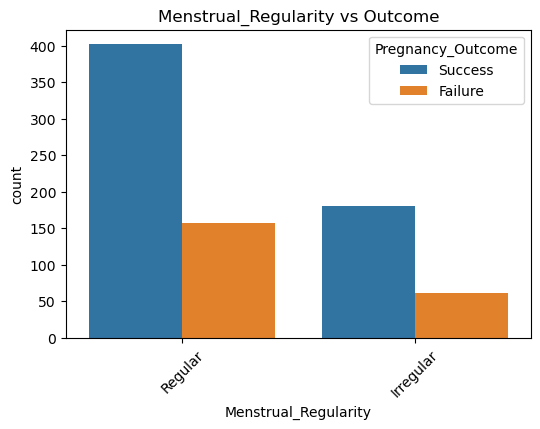

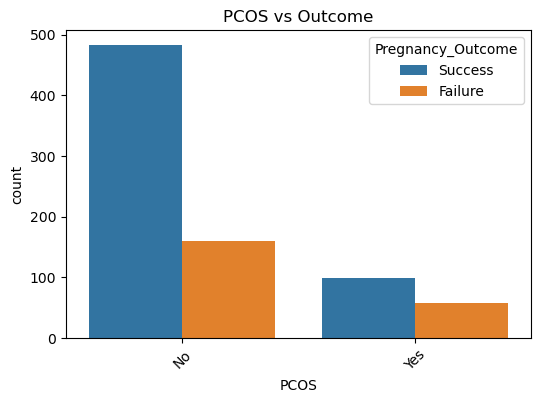

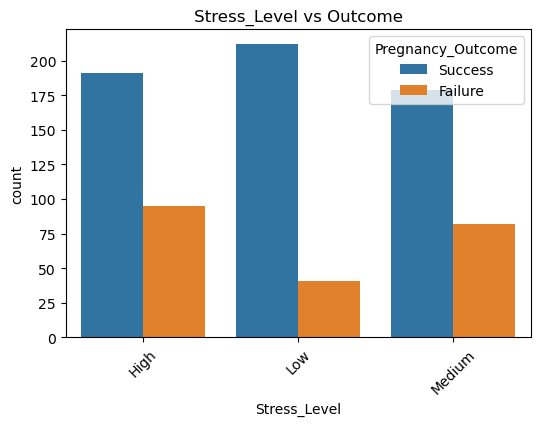

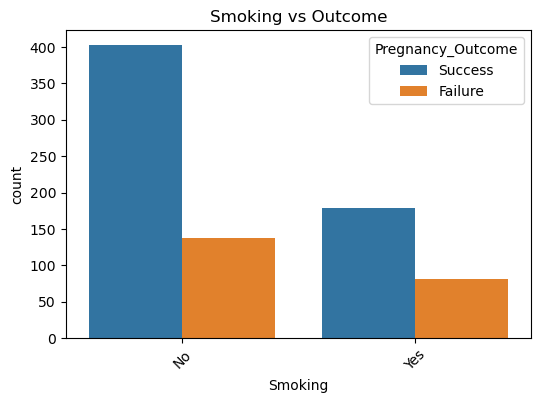

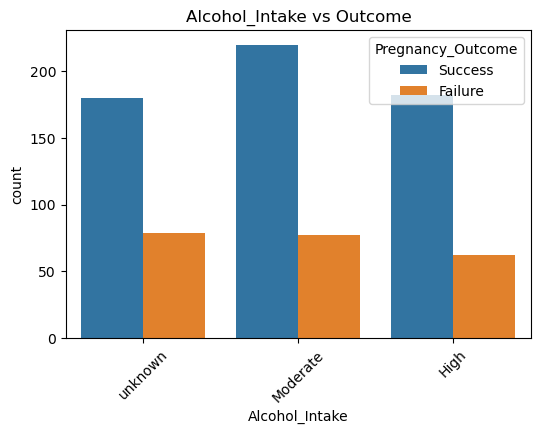

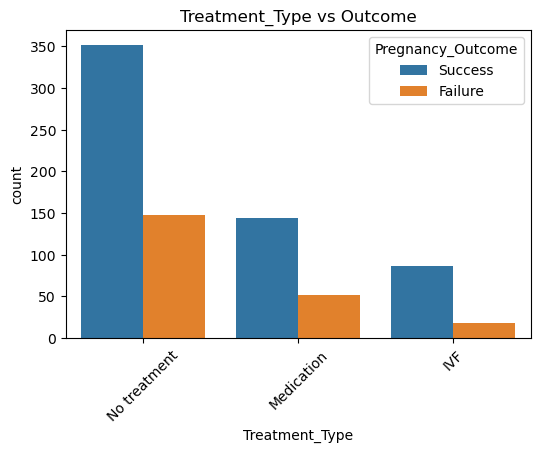

In [82]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    if col != 'Pregnancy_Outcome':
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col, hue='Pregnancy_Outcome')
        plt.title(f"{col} vs Outcome")
        plt.xticks(rotation=45)
        plt.show()

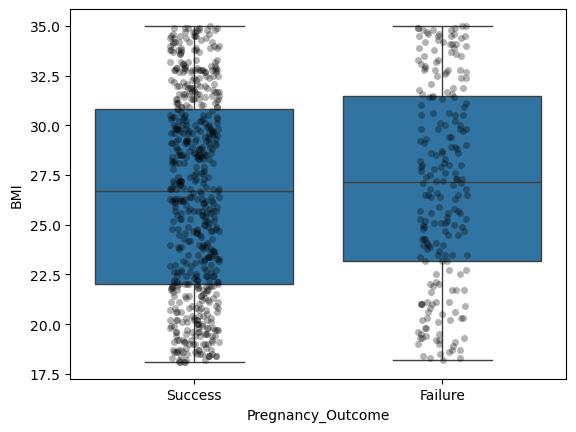

In [83]:
sns.boxplot(data=df, x='Pregnancy_Outcome', y='BMI')
sns.stripplot(data=df, x='Pregnancy_Outcome', y='BMI', color='black', alpha=0.3)
plt.show()

<Axes: xlabel='Pregnancy_Outcome', ylabel='Female_Age'>

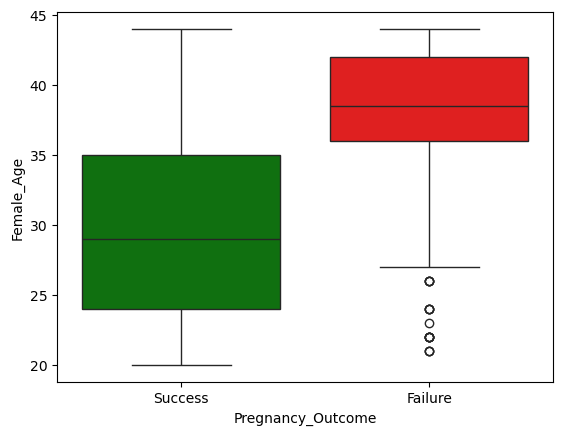

In [84]:
sns.boxplot(
    data=df,
    x='Pregnancy_Outcome',
    y='Female_Age',
    hue='Pregnancy_Outcome',
    palette={'Success':'green','Failure':'red'},
    legend=False
)

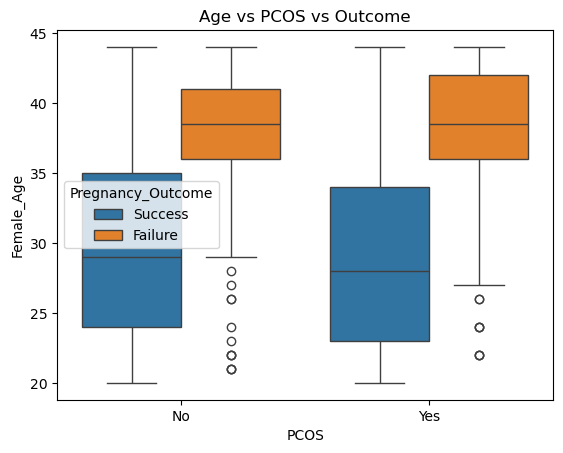

In [85]:
sns.boxplot(
    data=df,
    x='PCOS',
    y='Female_Age',
    hue='Pregnancy_Outcome'
)

plt.title("Age vs PCOS vs Outcome")
plt.show()

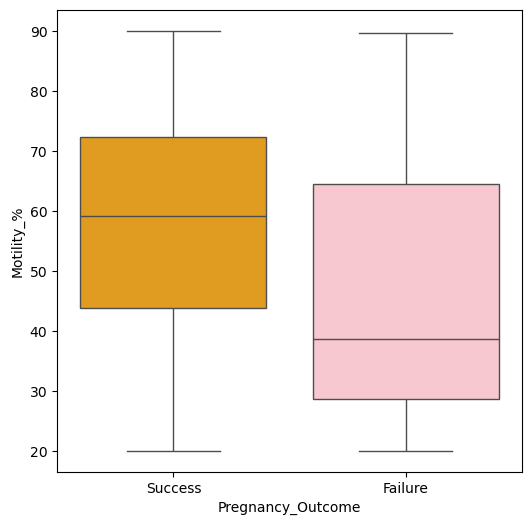

In [86]:
plt.figure(figsize=(6,6))
sns.boxplot(
    x='Pregnancy_Outcome',
    y='Motility_%',
    data=df,
    hue='Pregnancy_Outcome',   # required
    palette={'Success': 'orange', 'Failure': 'pink'},
    legend=False)               # remove duplicate legend
plt.show()

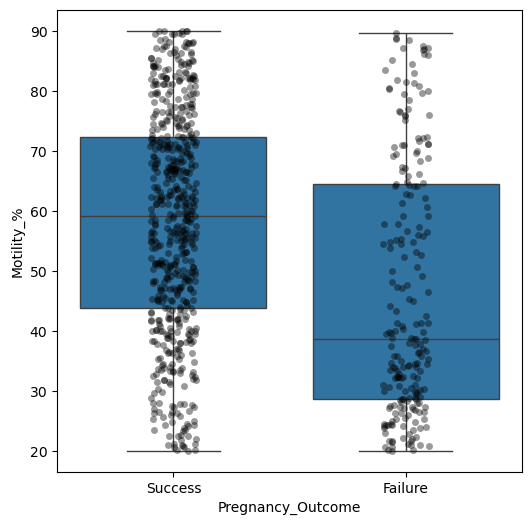

In [87]:
plt.figure(figsize=(6,6))

sns.boxplot(x='Pregnancy_Outcome', y='Motility_%', data=df)
sns.stripplot(x='Pregnancy_Outcome', y='Motility_%', data=df, color='black', alpha=0.4)

plt.show()

In [88]:
df.groupby('Pregnancy_Outcome')['Male_Age'].mean() 

Pregnancy_Outcome
Failure    34.752294
Success    35.443299
Name: Male_Age, dtype: float64

In [89]:
df.groupby('Pregnancy_Outcome')['Female_Age'].mean() 

Pregnancy_Outcome
Failure    37.56422
Success    29.78866
Name: Female_Age, dtype: float64

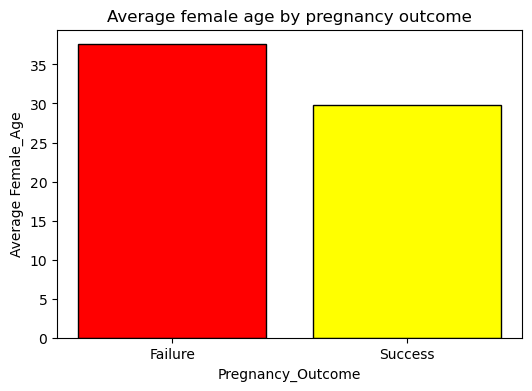

In [90]:
grade_int = df.groupby('Pregnancy_Outcome')['Female_Age'].mean()
colors = ["red", "yellow",]
plt.figure(figsize=(6,4))
plt.bar(x=grade_int.index, height=grade_int.values, color=colors, edgecolor="black")
plt.title("Average female age by pregnancy outcome")
plt.xlabel("Pregnancy_Outcome")
plt.ylabel("Average Female_Age")
plt.show()

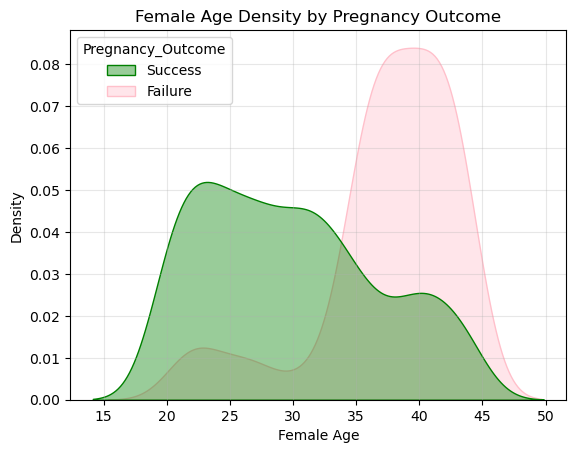

In [91]:
sns.kdeplot(
    data=df,
    x='Female_Age',
    hue='Pregnancy_Outcome',
    fill=True,
    common_norm=False,   # important for fair comparison
    palette={'Success':'green', 'Failure':'pink'},
    alpha=0.4
)

plt.title("Female Age Density by Pregnancy Outcome")
plt.xlabel("Female Age")
plt.ylabel("Density")

plt.grid(alpha=0.3)
plt.show()

### num-num

In [92]:
num_col

Index(['Female_Age', 'Male_Age', 'BMI', 'Sperm_Count_Million_per_ml',
       'Motility_%', 'Trying_Duration_Months'],
      dtype='object')

In [93]:
df[['Female_Age', 'Male_Age', 'BMI',
       'Sperm_Count_Million_per_ml', 'Motility_%', 'Trying_Duration_Months' ]].corr() 

 # Correlation tells how strongly two columns are related (from -1 to 1)
#+1-Strong positive relationship (when one goes up, other goes up)
 #0-No relationship
 #-1-Strong negative relationship (when one goes up, other goes down

,Female_Age,Male_Age,BMI,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months
Female_Age,1.000000,0.022288,0.030039,0.053754,-0.053457,-0.029563
Male_Age,0.022288,1.000000,0.037419,-0.030686,-0.053024,0.027104
BMI,0.030039,0.037419,1.000000,-0.042718,-0.007895,-0.001016
Sperm_Count_Million_per_ml,0.053754,-0.030686,-0.042718,1.000000,-0.038398,0.027758
Motility_%,-0.053457,-0.053024,-0.007895,-0.038398,1.000000,-0.031221
Trying_Duration_Months,-0.029563,0.027104,-0.001016,0.027758,-0.031221,1.000000


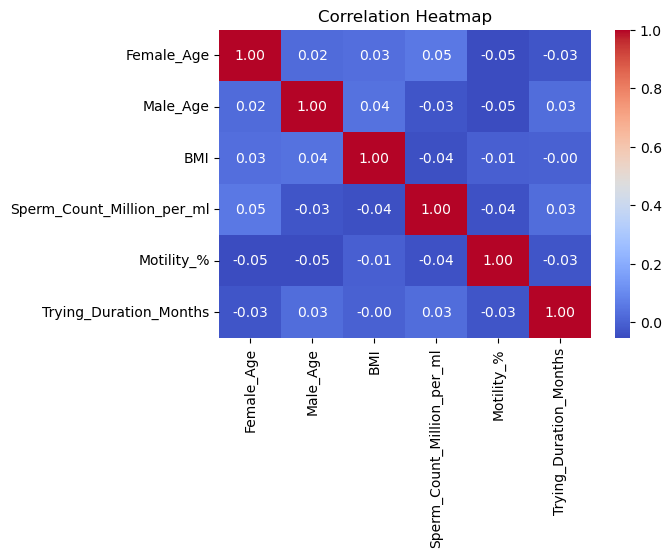

In [94]:
x= ['Female_Age', 'Male_Age', 'BMI',
       'Sperm_Count_Million_per_ml', 'Motility_%', 'Trying_Duration_Months']
corr = df[x].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [162]:

# 1. The correlation matrix shows very weak relationships among all numerical variables,
#    as most correlation values are close to zero.

# 2. No strong positive or negative correlation exists between any pair of variables,
#    indicating low multicollinearity within the dataset.

# 3. Low multicollinearity is beneficial for Logistic Regression because:
#       - model coefficients remain stable
#       - prediction reliability improves
#       - feature redundancy is minimized

# 4. Female_Age and Male_Age show almost no correlation (0.022),
#    suggesting partner ages vary independently in the dataset.

# 5. Female_Age has a very weak negative relationship with Motility_% (-0.053),
#    indicating age may slightly influence sperm motility, although the effect is minimal.

# 6. Male_Age also shows weak negative correlation with Motility_% (-0.053),
#    suggesting sperm motility may decline slightly with increasing male age.

# 7. BMI shows weak negative correlation with:
#       - Sperm_Count_Million_per_ml (-0.043)
#       - Motility_% (-0.008)
#    which may indicate higher BMI has a slight negative effect on fertility health.

# 8. Sperm_Count_Million_per_ml and Motility_% have very weak correlation (-0.038),
#    suggesting sperm quantity and movement quality behave independently in this dataset.

# 9. Trying_Duration_Months has negligible correlation with all variables,
#    indicating pregnancy attempt duration alone is not strongly driven by age,
#    BMI, or sperm health variables.

# 10. The absence of strong correlations suggests fertility outcomes are likely influenced
#     by combinations of multiple biological, medical, and lifestyle factors rather than
#     any single dominant feature.

# 11. Since direct linear relationships are weak, advanced feature engineering,
#     interaction features, and nonlinear models may improve predictive performance.

# 12. Overall, the dataset structure is suitable for machine learning because:
#       - variables are largely independent
#       - multicollinearity risk is low
#       - feature interpretability remains strong


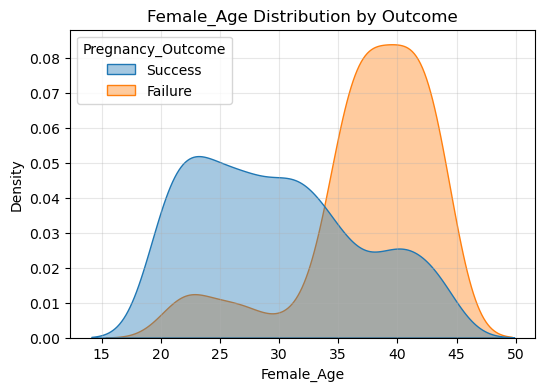

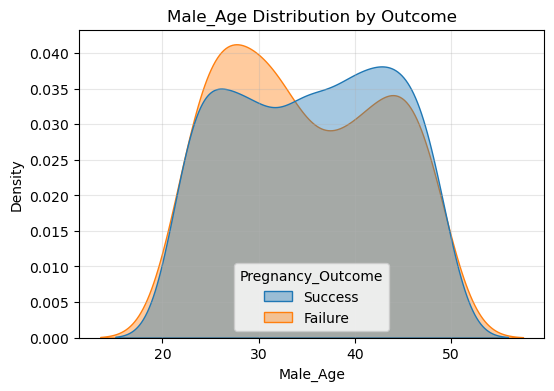

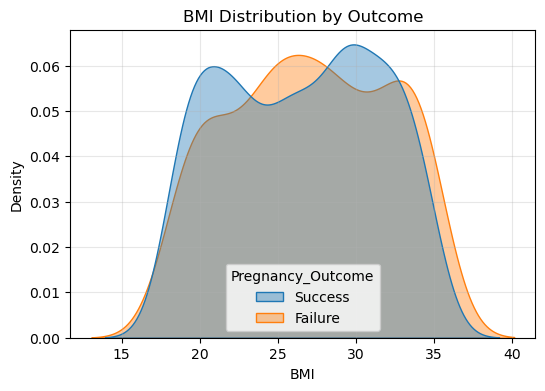

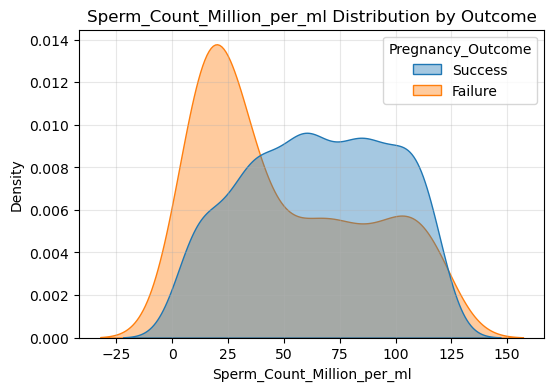

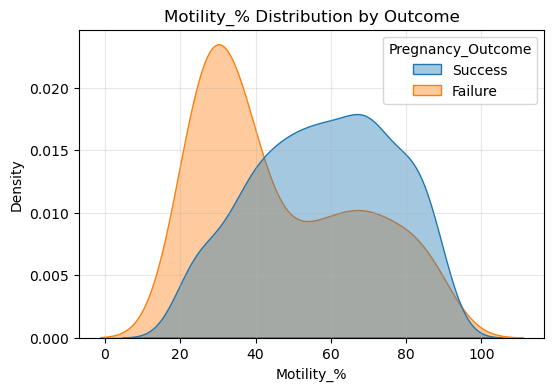

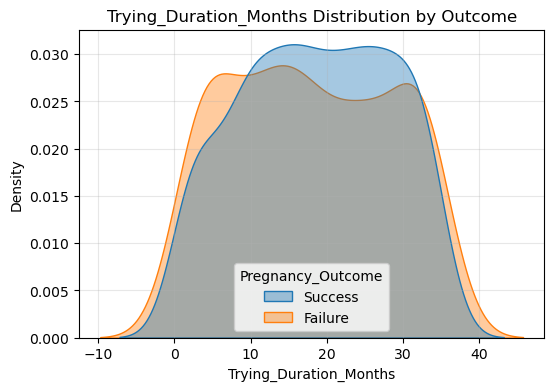

In [95]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col != 'Couple_ID':
        plt.figure(figsize=(6,4))
        
        sns.kdeplot(
            data=df,
            x=col,
            hue='Pregnancy_Outcome',
            fill=True,
            common_norm=False,
            alpha=0.4
        )
        
        plt.title(f"{col} Distribution by Outcome")
        plt.grid(alpha=0.3)
        plt.show()

In [96]:
df.duplicated().sum()

np.int64(0)

## outliers

In [99]:
import pandas as pd

num_cols = ['Female_Age', 'Male_Age', 'BMI',
            'Sperm_Count_Million_per_ml', 'Motility_%',
            'Trying_Duration_Months']

outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

outlier_summary

{'Female_Age': 0,
 'Male_Age': 0,
 'BMI': 0,
 'Sperm_Count_Million_per_ml': 0,
 'Motility_%': 0,
 'Trying_Duration_Months': 0}

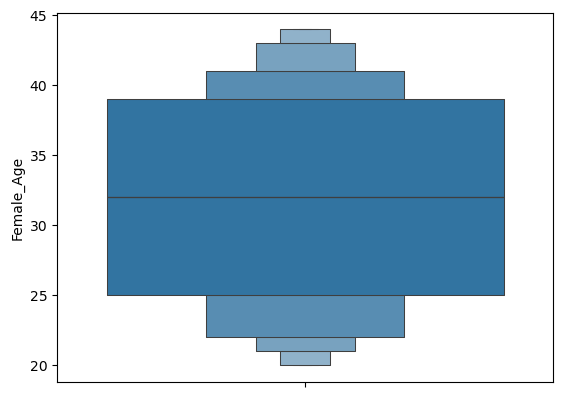

In [100]:
sns.boxenplot(data=df, y="Female_Age")
plt.show()

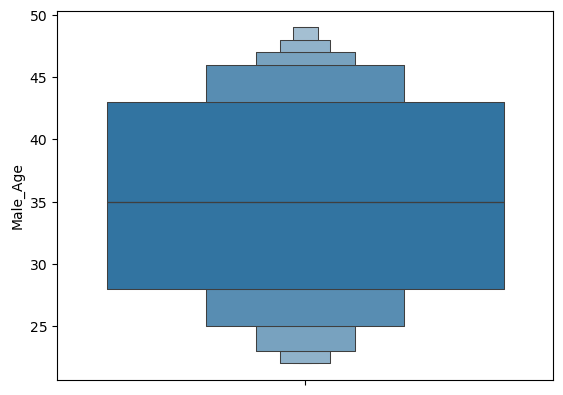

In [101]:
sns.boxenplot(data=df, y="Male_Age")
plt.show()

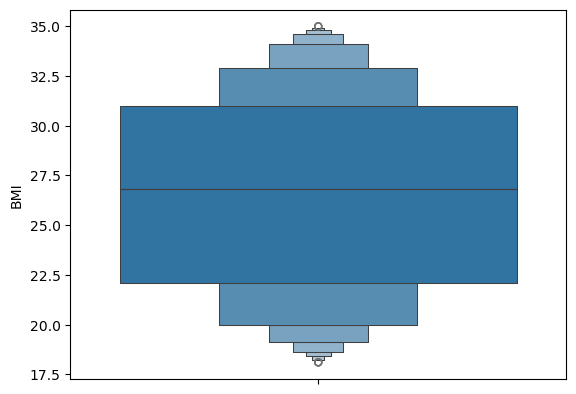

In [102]:
sns.boxenplot(data=df, y="BMI")
plt.show()

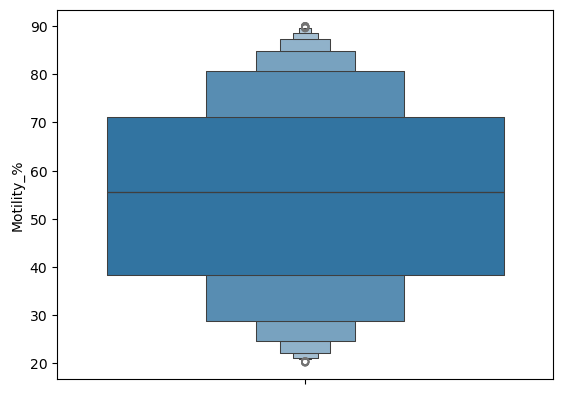

In [103]:
sns.boxenplot(data=df, y="Motility_%")
plt.show()

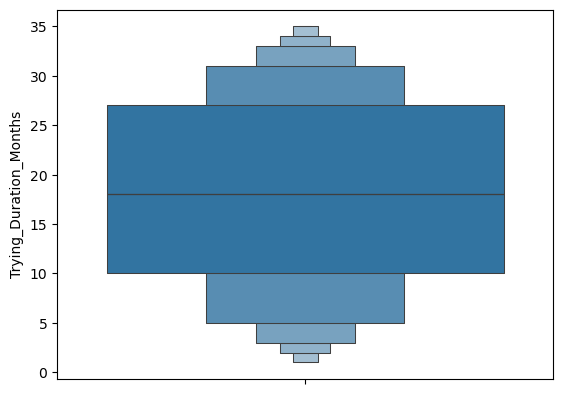

In [104]:
sns.boxenplot(data=df, y="Trying_Duration_Months")
plt.show()

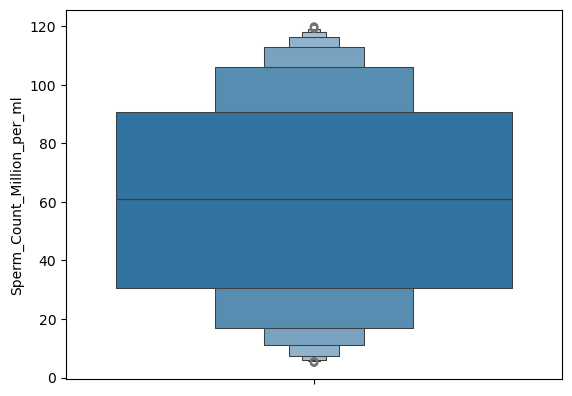

In [105]:
sns.boxenplot(data=df, y="Sperm_Count_Million_per_ml")
plt.show()

In [106]:
df.columns

Index(['Female_Age', 'Male_Age', 'BMI', 'Menstrual_Regularity', 'PCOS',
       'Stress_Level', 'Smoking', 'Alcohol_Intake',
       'Sperm_Count_Million_per_ml', 'Motility_%', 'Trying_Duration_Months',
       'Treatment_Type', 'Pregnancy_Outcome'],
      dtype='object')

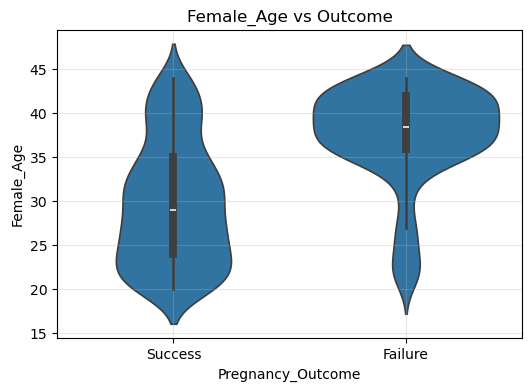

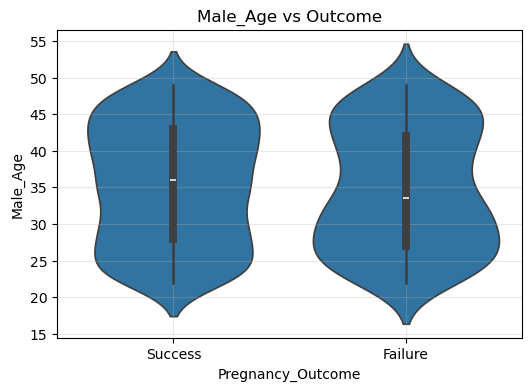

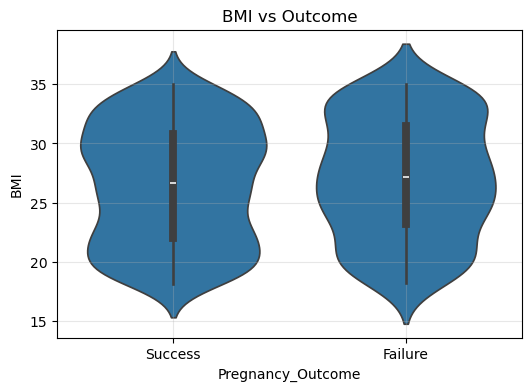

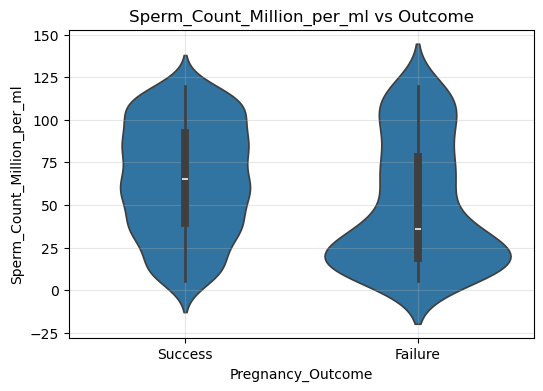

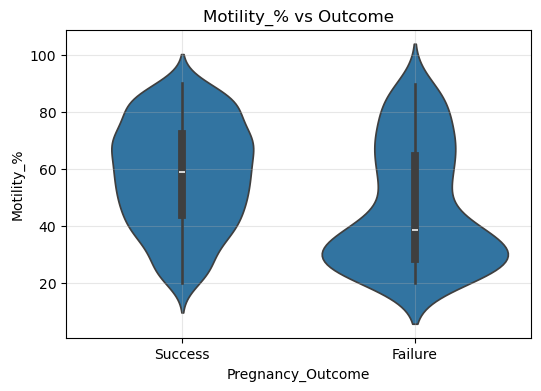

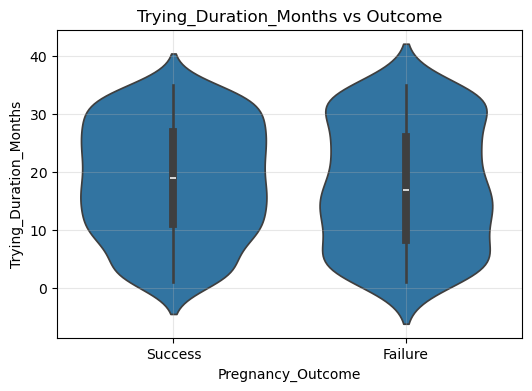

In [107]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col != 'Couple_ID':
        plt.figure(figsize=(6,4))
        
        sns.violinplot(
            data=df,
            x='Pregnancy_Outcome',
            y=col,
            inner='box'   # shows median + quartiles
        )
        
        plt.title(f"{col} vs Outcome")
        plt.grid(alpha=0.3)
        plt.show()

In [108]:
#“Violin plot combines boxplot and KDE, helping us understand both distribution shape and central tendency.”

# Example Insight:

#Wider shape → more data concentration
#Shift in shape → difference between success & failure
#Skewness → imbalance in distribution
#“The violin plot shows the distribution and density of values. 
#In my project, it helped identify that successful outcomes are concentrated at lower age ranges,
#while failures are more spread at higher ages.”

# insights

In [109]:
# DATASET INSIGHTS (EDA SUMMARY)

# 1. Female_Age:
# - Strong negative relationship with pregnancy success
# - Success cases ~29 yrs, Failure ~37 yrs
# - Threshold effect observed around age 35
# - Most important predictor in dataset

# 2. Motility_%:
# - Strong positive relationship with success
# - Success ~58%, Failure ~46%
# - Clear separation in boxplot and density
# - Best feature for model prediction

# 3. BMI:
# - Slightly higher in failure cases
# - High overlap between classes → weak/moderate predictor
# - Extreme BMI (obese) may reduce success probability

# 4. Trying_Duration_Months:
# - Longer duration → higher failure probability
# - >24 months indicates infertility risk
# - Moderate predictive power

# 5. Male_Age:
# - Almost same distribution in both classes
# - Very weak predictor

# 6. Smoking / Alcohol:
# - No strong direct impact on numerical features
# - Likely indirect or behavioral effect

# 7. Correlation Insights:
# - Sperm_Count ↑ → Motility ↑ (positive correlation)
# - Female_Age ↑ → Trying_Duration ↑
# - BMI mostly independent (low correlation with others)

# 8. Distribution Patterns:
# - Success clustered at lower age + higher motility
# - Failure clustered at higher age + lower motility

# 9. Outliers:
# - Present in BMI, Motility, Sperm_Count
# - Represent real medical extremes → do not blindly remove

# 10. Missing Data:
# - Treatment_Type ~60% missing
# - Alcohol_Intake ~30% missing
# - Requires imputation or category handling

# ============================
# FINAL FEATURE IMPORTANCE (EDA BASED)
# ============================

# Strong Features:
# - Female_Age
# - Motility_%

# Moderate Features:
# - Trying_Duration_Months
# - BMI

# Weak Features:
# - Male_Age
# - Smoking
# - Alcohol

#PCOS significantly reduces success rate
#Female age strongly impacts fertility
#Higher age → lower success probability


#Smoking + High Alcohol → lowest success
#Non-Smoking + Low Alcohol → highest success

In [110]:
# INSIGHTS

# The dataset indicates that fertility outcomes are influenced by a combination
# of biological, lifestyle, and medical factors rather than a single variable.

# Female age shows a strong relationship with pregnancy success, with success
# probability declining gradually after age 35, indicating age as a critical fertility factor.

# Male age also impacts fertility outcomes, but the effect appears less significant
# compared to female reproductive age.

# Patients with healthy BMI ranges demonstrated comparatively higher pregnancy success,
# while overweight and obese categories showed lower fertility outcomes.

# BMI appears to act as both a lifestyle and hormonal risk factor in fertility prediction.

# PCOS patients exhibited lower pregnancy success rates, suggesting that hormonal
# imbalance significantly affects reproductive health outcomes.

# PCOS-related fertility challenges may require more personalized treatment strategies
# and earlier medical intervention.

# Smoking behavior showed a negative association with pregnancy success, reinforcing
# the importance of lifestyle modification in fertility improvement programs.

# Alcohol consumption patterns may contribute to fertility risks, although additional
# behavioral and medical factors should also be considered for deeper analysis.

# Higher stress levels were associated with lower fertility success, highlighting the
# importance of psychological wellness in reproductive healthcare.

# Stress management may serve as an important non-medical intervention to improve
# fertility outcomes among high-risk patients.

# Irregular menstrual cycles appeared more frequently among unsuccessful pregnancy cases,
# indicating a potential relationship between hormonal irregularities and fertility issues.

# Higher sperm count levels generally correlated with improved pregnancy outcomes,
# emphasizing the importance of male fertility indicators in reproductive analysis.

# Sperm motility emerged as one of the strongest biological indicators affecting
# pregnancy success probability.

# Low motility cases may require advanced fertility treatments or earlier intervention.

# Fertility treatment effectiveness varied across patient groups, suggesting that
# treatment outcomes depend heavily on underlying medical and lifestyle conditions.

# Advanced fertility treatments may show higher success among patients receiving
# earlier diagnosis and intervention.

# Lifestyle-related variables such as smoking, stress, and BMI collectively showed
# a measurable impact on fertility outcomes.

# Preventive healthcare and lifestyle optimization may significantly improve
# reproductive success rates.

# The dataset contains class imbalance, with successful pregnancy cases appearing
# more frequently than unsuccessful cases, which may bias machine learning predictions.

# Logistic Regression performed effectively as a baseline classification model due to
# its interpretability and suitability for binary healthcare prediction tasks.

# The model achieved strong overall accuracy; however, lower recall for unsuccessful
# pregnancies indicates challenges in identifying high-risk fertility cases.

# Lower recall for unsuccessful pregnancy cases suggests that the model may miss some
# fertility-risk patients, which is particularly important in healthcare applications.

# Improving minority class detection through class balancing or advanced ensemble models
# could significantly enhance healthcare prediction reliability.

# The analysis demonstrates that fertility prediction is not solely dependent on medical
# treatment but is also strongly influenced by behavioral and lifestyle factors.

# Hospitals and fertility clinics can leverage predictive analytics to identify high-risk
# patients early and improve treatment planning efficiency.

# Early fertility screening, lifestyle counseling, and personalized treatment plans
# may substantially improve reproductive healthcare outcomes.

# This project highlights the potential of healthcare analytics and machine learning
# in supporting data-driven fertility prediction and reproductive healthcare decision-making.

### Top 3 Factors Affecting Fertility

In [111]:
#1. Age → Most critical factor; success rate drops significantly after 35
#2. Sperm Motility → Strong positive impact; higher motility increases chances
#3. PCOS → Major negative factor affecting pregnancy outcomes

### What Should Patients Do? (Recommendations)

In [112]:


# Convert target to numeric
df['Pregnancy_Outcome'] = df['Pregnancy_Outcome'].map({'Success': 1, 'Failure': 0})

# Select only numeric columns
num_df = df.select_dtypes(include=[np.number])

# Correlation with target
corr = num_df.corr()['Pregnancy_Outcome'].sort_values(ascending=False)

# Show top factors
print("Top Positive Factors:\n", corr.head(5))
print("\nTop Negative Factors:\n", corr.tail(5))

Top Positive Factors:
 Pregnancy_Outcome             1.000000
Motility_%                    0.262131
Sperm_Count_Million_per_ml    0.202675
Male_Age                      0.037467
Trying_Duration_Months        0.027733
Name: Pregnancy_Outcome, dtype: float64

Top Negative Factors:
 Sperm_Count_Million_per_ml    0.202675
Male_Age                      0.037467
Trying_Duration_Months        0.027733
BMI                          -0.047424
Female_Age                   -0.464258
Name: Pregnancy_Outcome, dtype: float64


In [163]:
# 1. Female_Age is the strongest predictor in the dataset with a strong
#    negative correlation (-0.464) with Pregnancy_Outcome.
#    This indicates pregnancy success decreases significantly as female age increases.

# 2. Sperm Motility (%) is the strongest positive fertility indicator (0.262),
#    suggesting higher sperm movement quality substantially improves
#    pregnancy success probability.

# 3. Sperm_Count_Million_per_ml also shows positive correlation (0.203),
#    confirming that better sperm concentration contributes to improved fertility outcomes.

# 4. Female reproductive aging appears to have a greater impact on fertility
#    outcomes than male age in this dataset.

# 5. BMI shows a weak negative relationship (-0.047) with pregnancy outcome,
#    indicating higher BMI may slightly reduce fertility success rates.

# 6. Male_Age and Trying_Duration_Months have very weak correlations,
#    suggesting they are not strong standalone predictors of pregnancy success.

# 7. The dataset indicates that fertility outcomes are primarily influenced by:
#       - Female reproductive age
#       - Sperm quality metrics
#    rather than demographic duration-based variables.

# 8. The absence of strong inter-feature correlations confirms low multicollinearity,
#    making the dataset suitable for Logistic Regression and interpretable ML models.

# 9. Since direct correlations are moderate rather than extremely high,
#    fertility prediction likely depends on combined interaction effects
#    between biological and lifestyle variables.

# 10. Business & Healthcare Insight:
#     Early fertility intervention and sperm quality assessment may significantly
#     improve pregnancy success probability, especially for higher-age female patients.


# Questions

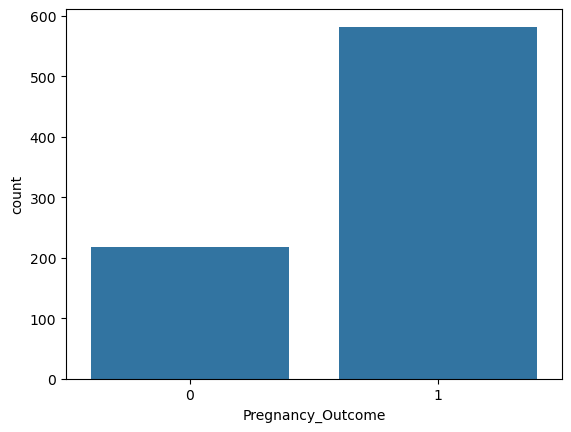

Pregnancy_Outcome
1    0.7275
0    0.2725
Name: proportion, dtype: float64


In [114]:
# 1.How can you identify and visualize class imbalance in Pregnancy_Outcome?
sns.countplot(x='Pregnancy_Outcome', data=df)
plt.show()

print(df['Pregnancy_Outcome'].value_counts(normalize=True))

In [115]:
#2.How do you calculate percentiles of sperm count?
percentiles = df['Sperm_Count_Million_per_ml'].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).T
percentiles

count    800.000000
mean      61.072000
std       34.207898
min        5.100000
1%         5.800000
10%       14.100000
25%       30.600000
50%       61.050000
75%       90.825000
90%      109.200000
99%      118.502000
max      119.900000
Name: Sperm_Count_Million_per_ml, dtype: float64

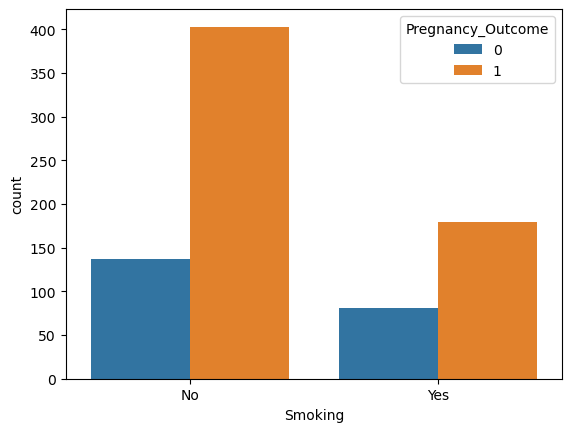

In [117]:
#4. How does Smoking affect pregnancy success rate?
sns.countplot(data=df, x='Smoking', hue='Pregnancy_Outcome')
plt.show()

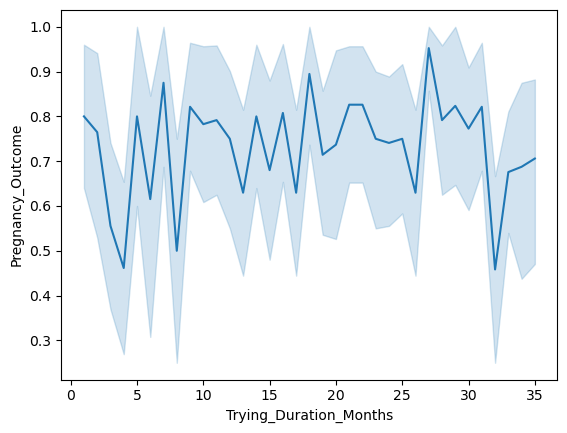

In [118]:
#5.How does Trying_Duration_Months relate to success?
sns.lineplot(data=df, x='Trying_Duration_Months', y='Pregnancy_Outcome')
plt.show()

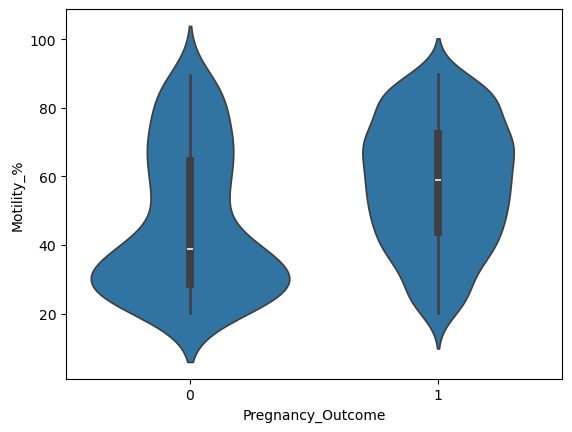

In [119]:
#6.How is Motility_% distributed across outcomes?
sns.violinplot(data=df, x='Pregnancy_Outcome', y='Motility_%')
plt.show()

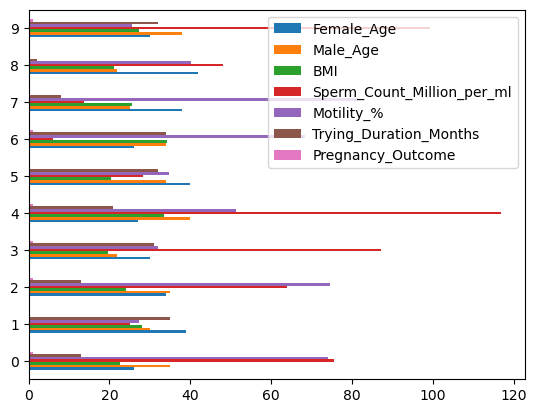

In [120]:
#7.Which features are most important for prediction?
df.head(10).plot(kind='barh')
plt.show()

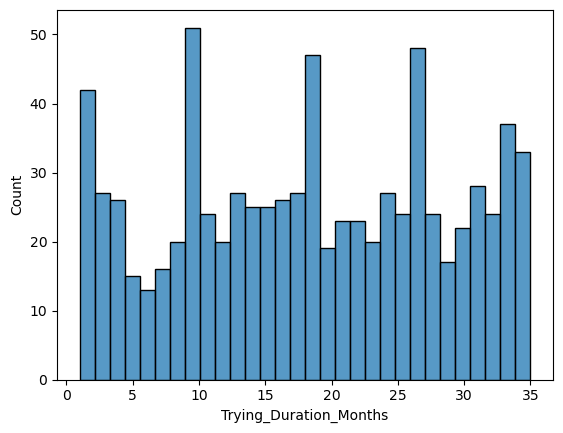

In [121]:
#8.Distribution of Trying_Duration_Months.
sns.histplot(df['Trying_Duration_Months'], bins=30)
plt.show()

In [122]:
#9.What is the median sperm count in the dataset?
df['Sperm_Count_Million_per_ml'].median()

61.05

In [123]:
#10.How do you normalize numerical features?
from sklearn.preprocessing import MinMaxScaler

num_cols = df.select_dtypes(include='number').columns

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [124]:
df[num_cols]

,Female_Age,Male_Age,BMI,Sperm_Count_Million_per_ml,Motility_%,Trying_Duration_Months,Pregnancy_Outcome
0,0.250000,0.481481,0.266272,0.614983,0.772532,0.352941,1.0
1,0.791667,0.296296,0.585799,0.175087,0.104435,1.000000,0.0
2,0.583333,0.481481,0.355030,0.513066,0.778255,0.352941,1.0
3,0.416667,0.000000,0.088757,0.716028,0.168813,0.882353,1.0
4,0.291667,0.666667,0.917160,0.973868,0.446352,0.588235,1.0
...,...,...,...,...,...,...,...
795,0.375000,0.629630,0.609467,0.909408,0.198856,0.764706,1.0
796,0.375000,0.148148,0.059172,0.604530,0.715308,0.794118,1.0
797,0.750000,0.407407,0.514793,0.527875,0.313305,0.441176,1.0
798,0.666667,0.407407,0.147929,0.557491,0.304721,0.941176,0.0


In [125]:
#11.How does BMI affect fertility outcomes?
df.groupby('Pregnancy_Outcome')['BMI'].mean()

Pregnancy_Outcome
0.0    0.528636
1.0    0.497163
Name: BMI, dtype: float64

In [126]:
#12.What is the distribution of Pregnancy_Outcome?
df['Pregnancy_Outcome'].value_counts(normalize=True) * 100

Pregnancy_Outcome
1.0    72.75
0.0    27.25
Name: proportion, dtype: float64

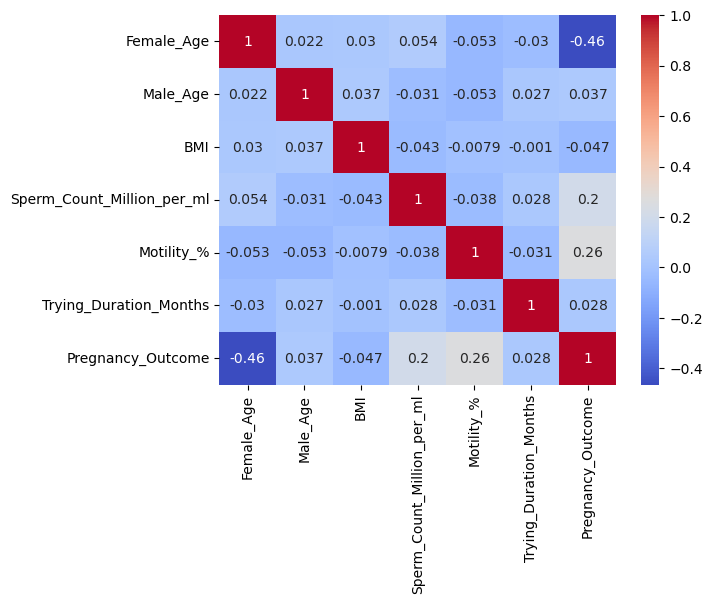

In [127]:
#13. What features are highly correlated?
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [164]:
# 1. The dataset shows low multicollinearity because no feature pair
#    has extremely high correlation (>0.8 or <-0.8).

# 2. Low multicollinearity is highly beneficial for Logistic Regression:
#       - coefficients remain stable
#       - model interpretability improves
#       - overfitting risk reduces

# 3. Female_Age has the strongest correlation with Pregnancy_Outcome (-0.46),
#    making it the most influential predictive feature in the dataset.

# 4. Motility_% (0.26) and Sperm_Count_Million_per_ml (0.20)
#    are the strongest positive fertility predictors.

# 5. Most independent variables have weak correlations with each other,
#    indicating low feature redundancy and healthier feature distribution.

# 6. Weak linear relationships among variables suggest that fertility outcomes
#    may depend more on combined interaction effects rather than single variables.


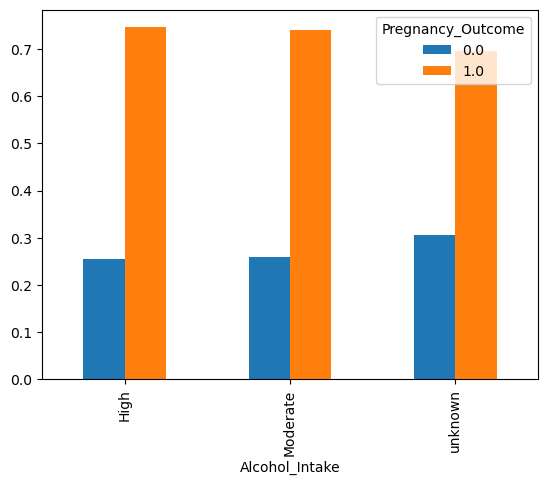

In [128]:
#14.Q: How does alcohol consumption affect success?
pd.crosstab(df['Alcohol_Intake'], df['Pregnancy_Outcome'], normalize='index').plot(kind='bar')
plt.show()


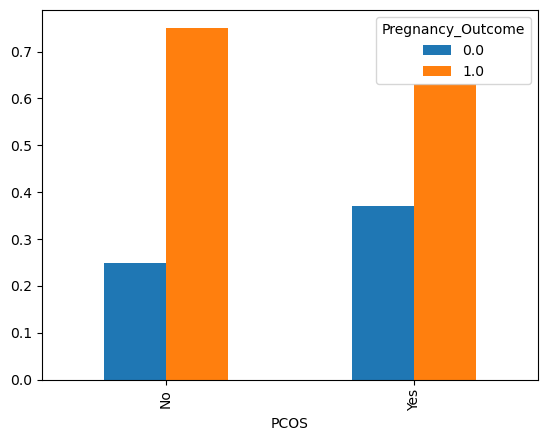

In [129]:
#15. How does PCOS affect success?
pd.crosstab(df['PCOS'], df['Pregnancy_Outcome'], normalize='index').plot(kind='bar')
plt.show()

### Model development

In [130]:
df.select_dtypes(include=[np.number]).columns

Index(['Female_Age', 'Male_Age', 'BMI', 'Sperm_Count_Million_per_ml',
       'Motility_%', 'Trying_Duration_Months', 'Pregnancy_Outcome'],
      dtype='object')

In [131]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [132]:
df = pd.get_dummies(df, drop_first=True)

In [133]:
df.select_dtypes(exclude=[np.number]).columns

Index(['Menstrual_Regularity_Regular', 'PCOS_Yes', 'Stress_Level_Low',
       'Stress_Level_Medium', 'Smoking_Yes', 'Alcohol_Intake_Moderate',
       'Alcohol_Intake_unknown', 'Treatment_Type_Medication',
       'Treatment_Type_No treatment'],
      dtype='object')

In [134]:
df=pd.get_dummies(data=df, 
               columns=['Menstrual_Regularity_Regular', 'PCOS_Yes', 'Stress_Level_Low',
       'Stress_Level_Medium', 'Smoking_Yes', 'Alcohol_Intake_Moderate',
       'Alcohol_Intake_unknown', 'Treatment_Type_Medication',
       'Treatment_Type_No treatment'], dtype="int", drop_first=True)

In [135]:
feature=['Female_Age', 'Male_Age', 'BMI',
       'Sperm_Count_Million_per_ml', 'Motility_%', 'Trying_Duration_Months']
target=['Pregnancy_Outcome']

In [136]:
x = df.drop('Pregnancy_Outcome', axis=1)
y = df['Pregnancy_Outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [137]:
model0=LogisticRegression(max_iter=10000)

In [138]:
model0.fit(x_train, y_train)

LogisticRegression(max_iter=10000)

In [151]:
model0.score(x_train, y_train)*100 #accuracy

82.8125

In [152]:
model0.score(x_test, y_test)*100  #accuracy

84.375

### model evaluate

In [153]:
from sklearn import metrics # R^2, MSE, RMSE etc..

In [154]:
#builtin
pred_train=model0.predict(x_train)
pred_test=model0.predict(x_test)

In [155]:
pd.DataFrame(metrics.confusion_matrix(y_train, pred_train),                #train
             index=["act0", "act1"], columns=["prd0", "pred1"])

,prd0,pred1
act0,100,74
act1,36,430


In [156]:
430/(36	+430)

0.9227467811158798

In [157]:
pd.DataFrame(metrics.confusion_matrix(y_test, pred_test),                #test
             index=["act0", "act1"], columns=["prd0", "pred1"])

,prd0,pred1
act0,25,19
act1,6,110


In [158]:
110/(6+110)


0.9482758620689655

In [159]:
from sklearn import metrics

print(metrics.classification_report(y_train, pred_train))

              precision    recall  f1-score   support

         0.0       0.74      0.57      0.65       174
         1.0       0.85      0.92      0.89       466

    accuracy                           0.83       640
   macro avg       0.79      0.75      0.77       640
weighted avg       0.82      0.83      0.82       640



In [160]:
print(metrics.classification_report(y_test, pred_test))       #test

              precision    recall  f1-score   support

         0.0       0.81      0.57      0.67        44
         1.0       0.85      0.95      0.90       116

    accuracy                           0.84       160
   macro avg       0.83      0.76      0.78       160
weighted avg       0.84      0.84      0.83       160



#### Biggest Problem
Low Recall for Class 0

This means:Model struggles detecting unsuccessful pregnancies,risky fertility cases

Healthcare projects require:high sensitivity toward risky cases.

In [161]:

# 1. The Logistic Regression model achieved:
#       - Training Accuracy  = 82.81%
#       - Testing Accuracy   = 84.37%
#    indicating strong and stable predictive performance.

# 2. Since test accuracy is slightly higher than train accuracy,
#    the model demonstrates good generalization capability and
#    shows no significant signs of overfitting.

# 3. The close alignment between train and test performance confirms
#    that the model is learning meaningful fertility-related patterns
#    rather than memorizing the training data.

# 4. Classification metrics reveal that the model performs exceptionally
#    well in predicting positive pregnancy outcomes (Class 1):
#       - Precision = 85%
#       - Recall    = 95%
#       - F1-score  = 90%
#    This indicates the model is highly effective at identifying
#    successful pregnancy-related cases.

# 5. High Recall (95%) for Class 1 is particularly important in
#    healthcare analytics because it minimizes the risk of missing
#    potential positive fertility outcomes.

# 6. The model shows comparatively weaker performance for Class 0:
#       - Recall = 57%
#    suggesting that some negative pregnancy outcomes are still
#    being incorrectly classified as positive.

# 7. The lower recall for Class 0 may indicate:
#       - Class imbalance
#       - Overlapping feature distributions
#       - Limited discriminatory power in certain variables

# 8. Weighted average metrics are higher than macro averages,
#    which confirms that the model performs better on the majority class.

# 9. From a business and healthcare perspective, the current model
#    behavior is acceptable if the primary objective is to identify
#    maximum successful pregnancy cases rather than minimizing false alarms.

# 10. Logistic Regression performed efficiently despite being a
#     relatively simple and interpretable algorithm, making it
#     suitable for explainable healthcare prediction systems.

# 11. The model can support:
#       - Fertility success prediction
#       - Patient risk segmentation
#       - Treatment outcome analysis
#       - Early intervention decision-making

# 12. Recommended next-step improvements:
#       - Apply SMOTE or class balancing techniques
#       - Perform hyperparameter tuning
#       - Engineer more domain-specific fertility features
#       - Evaluate advanced ensemble models
#       - Optimize decision threshold for better Class 0 recall

# 13. Final Strategic Insight:
#     The Logistic Regression model demonstrates strong real-world
#     predictive capability with stable generalization performance.
#     It is highly effective in identifying positive pregnancy outcomes,
#     making it a reliable baseline model for fertility healthcare analytics
#     and decision-support systems.

